In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Load final processed CSV
# -----------------------------
CSV = Path("../../data/gravity/Onyx_Gravity_LiDAR_Terrain_Corrected.csv")
df = pd.read_csv(CSV)

OUT = Path("../../figures/Final_figures")
OUT.mkdir(exist_ok=True)

x = df["station"].astype(float)

def rel(y):
    """Plot values relative to their own mean so processing stages compare clearly."""
    return y - np.nanmean(y)

def detrend(y, x=x):
    """Remove best-fit linear regional trend."""
    p = np.polyfit(x, y, 1)
    return y - np.polyval(p, x)

df

,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,...,gps_elevation_m,easting_m,northing_m,dem_elevation_m_at_station_raw,dem_vertical_shift_m,dem_elevation_m_at_station,gps_minus_dem_elevation_m,obs_height_used_m,harmonica_topography_effect_mgal,gravity_harmonica_lidar_corrected_mgal
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,...,2112.468,344418.058854,4.482505e+06,2124.461284,-12.548406,2111.912878,0.555122,2112.718,-0.328861,1.209589
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,...,2112.006,344417.830475,4.482506e+06,2124.390225,-12.548406,2111.841820,0.164180,2112.256,-0.318606,0.982289
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,...,2111.569,344417.640938,4.482507e+06,2124.322714,-12.548406,2111.774309,-0.205309,2111.819,-0.350946,0.964944
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,...,2111.692,344417.436458,4.482508e+06,2124.256692,-12.548406,2111.708286,-0.016286,2111.942,-0.355385,1.018615
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,...,2111.862,344417.349965,4.482509e+06,2124.173364,-12.548406,2111.624958,0.237042,2112.112,-0.365834,1.096921
5,6.0,0.502149,2111.790,40.478711,-106.835506,0.594055,0.215510,0.123603,CG5-2,-106.835506,...,2111.790,344417.201845,4.482510e+06,2124.092588,-12.548406,2111.544182,0.245818,2112.040,-0.370131,1.087790
6,7.0,0.412767,2111.286,40.478721,-106.835508,0.438521,0.159085,0.133332,CG5-2,-106.835508,...,2111.286,344417.061740,4.482511e+06,2124.019241,-12.548406,2111.470835,-0.184835,2111.536,-0.373878,0.945731
7,8.0,0.402282,2111.152,40.478730,-106.835512,0.397168,0.144084,0.149197,CG5-2,-106.835512,...,2111.152,344416.771637,4.482512e+06,2123.954159,-12.548406,2111.405753,-0.253753,2111.402,-0.401143,0.947509
8,9.0,0.428428,2111.213,40.478738,-106.835512,0.415993,0.150913,0.163348,CG5-2,-106.835512,...,2111.213,344416.758564,4.482513e+06,2123.888064,-12.548406,2111.339658,-0.126658,2111.463,-0.404621,0.983962
9,10.0,0.429741,2111.151,40.478747,-106.835513,0.396860,0.143972,0.176853,CG5-2,-106.835513,...,2111.151,344416.684254,4.482514e+06,2123.812516,-12.548406,2111.264110,-0.113110,2111.401,-0.408519,0.982232


KeyError: 'gravity_free_air_only_mgal'

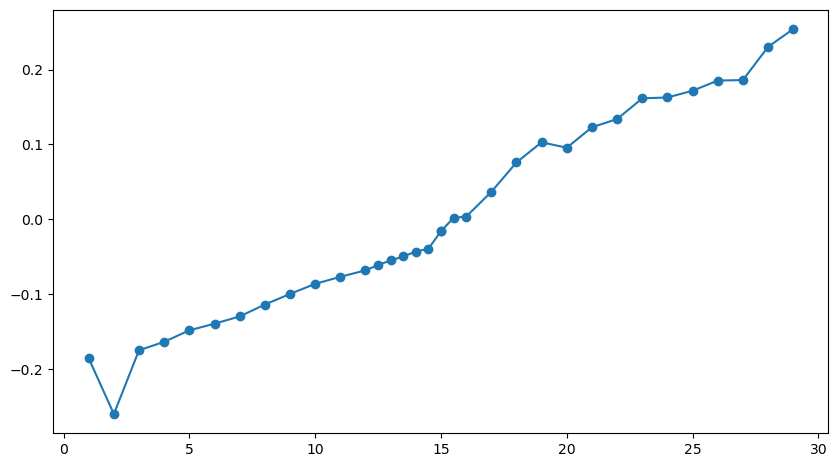

In [4]:
# -----------------------------
# Figure 1: Processing stages, normalized
# -----------------------------
plt.figure(figsize=(10, 5.5))

plt.plot(x, rel(df["gravity_tied_mgal"]), "o-", label="Drift + instrument tied")
plt.plot(x, rel(df["gravity_free_air_only_mgal"]), "o-", label="Free-air corrected")
plt.plot(x, rel(df["gravity_harmonica_lidar_corrected_mgal"]), "o-", label="LiDAR terrain corrected")

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station position along line (m)")
plt.ylabel("Gravity relative to line mean (mGal)")
#plt.title("Gravity Processing Stages")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(OUT / "Grav_01_processing_stages_relative.png", dpi=300)
plt.show()



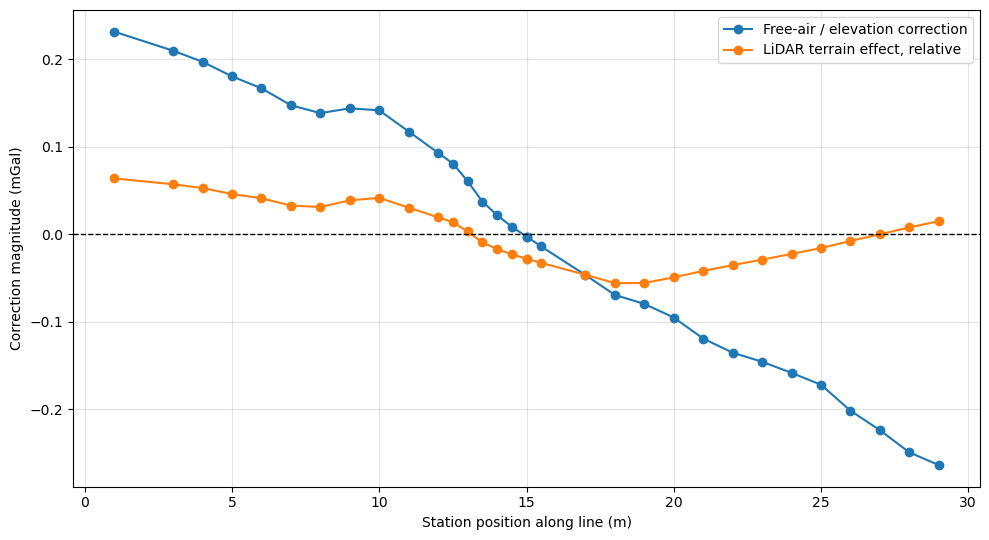

In [6]:
# -----------------------------
# Figure 2: Correction terms only
# -----------------------------
plt.figure(figsize=(10, 5.5))

plt.plot(x, rel(df["free_air_correction_mgal"]), "o-", label="Free-air / elevation correction")
plt.plot(x, df["harmonica_gz_relative_mgal"], "o-", label="LiDAR terrain effect, relative")

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station position along line (m)")
plt.ylabel("Correction magnitude (mGal)")
#plt.title("Elevation and LiDAR Terrain Correction Terms")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(OUT / "Grav_02_Elev_LiDAR_Corrections.png", dpi=300)
plt.show()



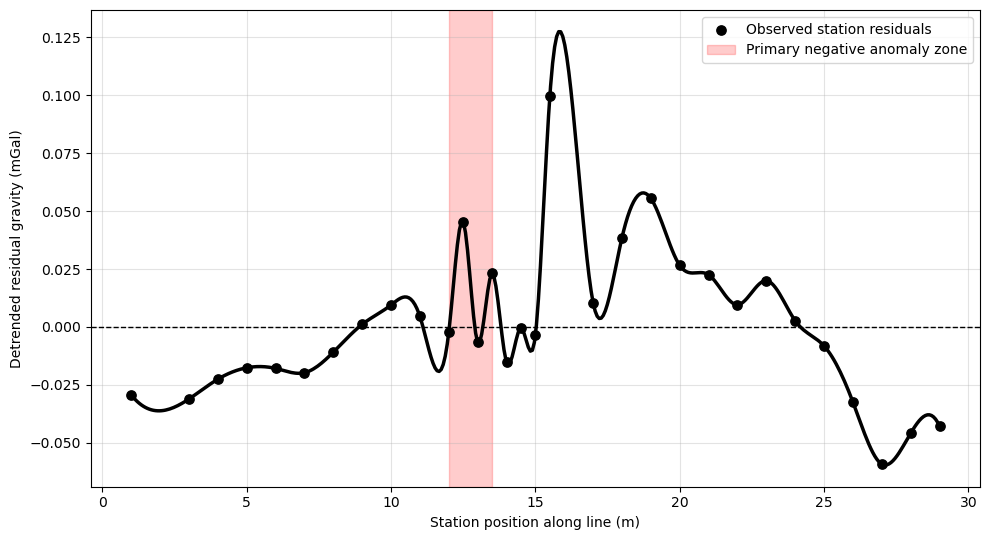

In [7]:
# # -----------------------------
# # Figure 3: Final residual anomaly after removing regional trend
# # -----------------------------
# final = df["gravity_harmonica_lidar_corrected_mgal"].astype(float)
# resid = detrend(final)

# plt.figure(figsize=(10, 5.5))
# plt.plot(x, resid, "ko-", label="Final LiDAR-corrected residual")

# # highlight likely mine-shaft anomaly zone
# plt.axvspan(12, 13.5, alpha=0.2, label="Primary negative anomaly zone")

# plt.axhline(0, color="k", linestyle="--", linewidth=1)
# plt.xlabel("Station position along line (m)")
# plt.ylabel("Detrended residual gravity (mGal)")
# #plt.title("Final Residual Gravity Anomaly")
# plt.legend()
# plt.grid(True, alpha=0.35)
# plt.tight_layout()
# plt.savefig(OUT / "Grav_03_final_residual_anomaly.png", dpi=300)
# plt.show()

from scipy.interpolate import make_interp_spline

# -----------------------------
# Figure 3: Final residual anomaly after removing regional trend
# -----------------------------
final = df["gravity_harmonica_lidar_corrected_mgal"].astype(float)
resid = detrend(final)

# Put x and residual into one dataframe
plot_df = pd.DataFrame({
    "x": x,
    "resid": resid
})

# Sort and average duplicate station positions
plot_df = (
    plot_df
    .groupby("x", as_index=False)
    .mean()
    .sort_values("x")
)

x_plot = plot_df["x"].to_numpy()
resid_plot = plot_df["resid"].to_numpy()

# Smooth curve
x_smooth = np.linspace(x_plot.min(), x_plot.max(), 400)
spline = make_interp_spline(x_plot, resid_plot, k=3)
resid_smooth = spline(x_smooth)

plt.figure(figsize=(10, 5.5))

plt.plot(
    x_smooth,
    resid_smooth,
    color="black",
    linewidth=2.5,
    #label="Smoothed LiDAR-corrected residual"
)

plt.scatter(
    x_plot,
    resid_plot,
    color="black",
    s=45,
    zorder=5,
    label="Observed station residuals"
)

plt.axvspan(
    12,
    13.5,
    alpha=0.2,
    color="red",
    label="Primary negative anomaly zone"
)

plt.axhline(0, color="k", linestyle="--", linewidth=1)

plt.xlabel("Station position along line (m)")
plt.ylabel("Detrended residual gravity (mGal)")
plt.legend()
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(
    OUT / "Grav_03_final_residual_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

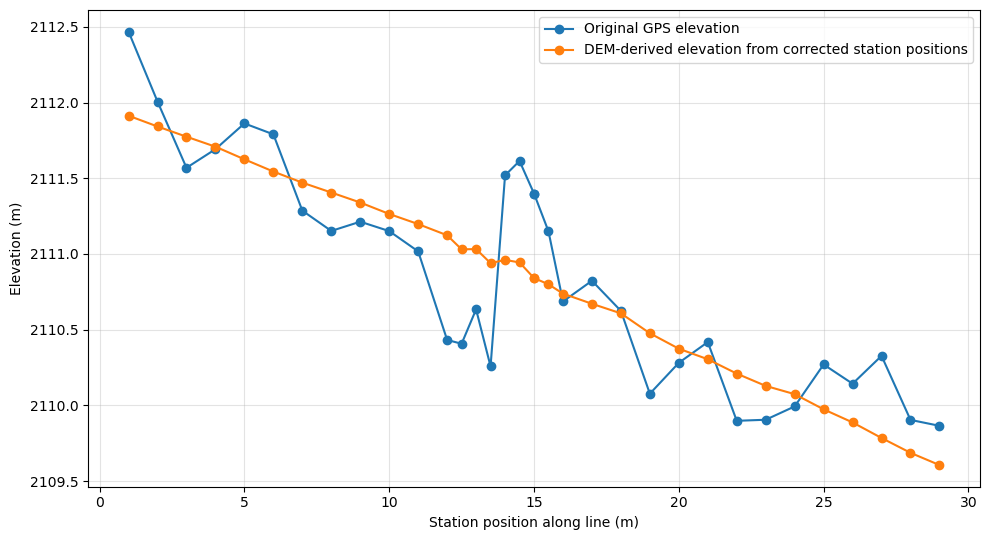

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../../data/gravity/Onyx_Gravity_LiDAR_Terrain_Corrected.csv"
)

df = df.sort_values("station")

plt.figure(figsize=(10,5.5))

plt.plot(
    df["station"],
    df["gps_elevation_m"],
    "o-",
    label="Original GPS elevation"
)

plt.plot(
    df["station"],
    df["dem_elevation_m_at_station"],
    "o-",
    label="DEM-derived elevation from corrected station positions"
)

plt.xlabel("Station position along line (m)")
plt.ylabel("Elevation (m)")
#plt.title("GPS Elevation vs Corrected DEM-Derived Elevation")

plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUT / "Grav_Elevations_GPS_DEM.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()